# Optuna를 활용한 하이퍼파라미터 최적화

## 개요
- Pima Indians Diabetes 데이터셋으로 **당뇨병 발병 여부** 예측
- **Optuna**: 베이지안 최적화 기반의 차세대 하이퍼파라미터 튜닝 프레임워크
- **3가지 Gradient Boosting 모델** 최적화: XGBoost, LightGBM, CatBoost
- Optuna vs GridSearch vs RandomSearch 성능 비교

## 주요 단계
1. 데이터 로드 및 분리
2. Optuna 기본 사용법
3. 각 모델별 Optuna 최적화
4. 최적화 과정 시각화
5. 다른 방법과 비교 분석

In [8]:
from matplotlib.pyplot import title
!pip install optuna catboost koreanize-matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Optuna
import optuna
from optuna import Trial
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour
)

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Optuna 로깅 레벨 조정
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 랜덤 시드 고정
RANDOM_STATE = 42

## 1. 데이터 로드

**Pima Indians Diabetes**
- 당뇨병 발병 여부 이진 분류
- feature: 임신 횟수, 혈당, 혈압, 피부두께, 인슐린, BMI, 당뇨병 가족력, 나이

In [10]:
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
X=pima.data
y=pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")
print(f"\n클래스 비율:\n{y.value_counts(normalize=True).round(4)}")
print(f"\n기술 통계:\n{X.describe()}")

데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
class
0    500
1    268
Name: count, dtype: int64

클래스 비율:
class
0    0.651
1    0.349
Name: proportion, dtype: float64

기술 통계:
             preg        plas        pres        skin        insu        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000  199.000000  122.000000   99.000000  846.000000   67.100000   

             pedi         age  
count  768.00

In [11]:
# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {X_train.shape}, y_test: {X_test.shape}")

X_train: (614, 8), X_test: (154, 8)
y_train: (614, 8), y_test: (154, 8)


## 2. 모델 별 Optuna 최적화하기
- Study: 최적화 세션 (하나의 최적화 작업)
- Trial: 하이퍼파라미터 조합 하나의 시도
- Objective Function: 최적화할 목표 함수
- Sampler: 파라미터 탐색 알고리즘 (기본: TPE)

**최적화 전략**
- 각 모델의 특성에 맞는 파라미터 범위 설정
- 교차 검증으로 안정적인 평가
- 충분한 시도 횟수 (50-100회)

In [12]:
"""
    Optuna 목적 함수(Objective Function) - 어떤 하이퍼파라미터 조합이 좋은지 평가하는 함수
    - trial: Optuna 제공 하이퍼파라미터 제안 객체
    - return: 최대/최소화 할 지표
"""

# XGBoost Optuna 최적화
def objective_xgboost(trial):    # trial: 시도할 실험 정보
    # 하이퍼파라미터 탐색 공간 정의
    # L1+L2 => Elastic Net 효과
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),     # 트리 개수 선택
        'max_depth': trial.suggest_int('max_depth', 3, 15),     # 트리 깊이 선택
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),   # 학습률 선택
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),    # 각 트리 생성 시 데이터 샘플 비율
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),   # leaf node 되기 위한 최소 데이터 가중치 합
        'gamma': trial.suggest_float('gamma', 0.0, 0.5),    # 분할 시 필요한 최소 손실 감소량
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),    # L1정규화(Lasso)
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),  # L2정규화(Ridge)
        'random_state': RANDOM_STATE,   # 랜덤 시드
        'eval_metric': 'logloss',   # XGBoost 내부 평가 지표 - 로그 손실(분류문제)
        'use_label_encoder': False  # XGBoost 경고 메시지 방지용 설정
    }

    # 모델 생성 및 평가
    model = XGBClassifier(**params)

    # 교차 검증 점수 (최대화할 지표)
    cv_score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,       # 5-Fold Cross Validation
        scoring='accuracy',
        n_jobs=-1
    ).mean()

    return cv_score


"""
    Optuna Study 생성(최대화 목표) - 하이퍼파라미터 최적화 실험환경(study) 생성
    - study: 여러 trial(실험)들을 관리하는 전체 프로젝트
"""
study_xgb = optuna.create_study(
    direction='maximize',   # 점수 최대화(accuracy가 클수록 좋은 모델)
    study_name='xgboost_full'     # study 이름
)

# 최적화 실행
print("\n최적화 시작 (50회 시도)...")
start_time = time.time()
study_xgb.optimize(objective_xgboost, n_trials=50, show_progress_bar=True)
xgb_time = time.time() - start_time

# 결과 출력
print(f"\n XGBoost 최적화 완료! (소요 시간: {xgb_time:.2f}초)")
print(f"최고 정확도: {study_xgb.best_value:.4f}")
print(f"\n최적 하이퍼파라미터:")
for param, value in study_xgb.best_params.items():
    print(f"  {param}: {value}")


최적화 시작 (50회 시도)...


Best trial: 38. Best value: 0.783393: 100%|██████████| 50/50 [00:01<00:00, 31.72it/s]


 XGBoost 최적화 완료! (소요 시간: 1.58초)
최고 정확도: 0.7834

최적 하이퍼파라미터:
  n_estimators: 87
  max_depth: 14
  learning_rate: 0.04637063013605776
  subsample: 0.7164717582116257
  min_child_weight: 9
  gamma: 0.1599049055146552
  reg_alpha: 0.4903724925476173
  reg_lambda: 0.35586322548016763


In [13]:
# LightGBM Optuna 최적화하기
# 최적함수 - trial
def objective_lgbm(trial):
    # 하이퍼파라미터 탐색 공간 정의
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100), # 최대 leaf 개수
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),  # 각 tree 생성 시 사용하는 feature 비율
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': RANDOM_STATE,
        'verbose': -1
    }

    model = LGBMClassifier(**params)
    cv_score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    ).mean()
    return cv_score

# study 생성 및 최적화
study_lgbm = optuna.create_study(
    direction='maximize',
    study_name='lightgbm_full'
)

# 결과 출력
start_time = time.time()
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)
lgbm_time = time.time() - start_time

print(f"\n LightGBM 최적화 완료! (소요 시간: {lgbm_time:.2f}초)")
print(f"최고 정확도: {study_lgbm.best_value:.4f}")
print(f"\n최적 하이퍼파라미터:")
for param, value in study_lgbm.best_params.items():
    print(f"  {param}: {value}")

Best trial: 8. Best value: 0.778542: 100%|██████████| 50/50 [00:39<00:00,  1.25it/s]


 LightGBM 최적화 완료! (소요 시간: 39.89초)
최고 정확도: 0.7785

최적 하이퍼파라미터:
  n_estimators: 120
  learning_rate: 0.02067648474395342
  num_leaves: 25
  max_depth: 15
  min_child_samples: 33
  subsample: 0.6645759012698479
  colsample_bytree: 0.9490894625719035
  reg_alpha: 0.9080250723445739
  reg_lambda: 0.45148315311495446


In [15]:
# CatBoost Optuna 최적화
# 최적함수 - trial
def objective_catboost(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),   # leaf weight에 대한 L2 정규화
        'border_count': trial.suggest_int('border_count', 32, 255), # 연속형 feature 구간(bin) 개수 나누기
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),    # 샘플링 랜덤성 조절
        'random_strength': trial.suggest_float('random_strength', 0, 10),   # split score 계산 시 랜덤 노이즈 추가 정도
        'random_state': RANDOM_STATE,
        'verbose': 0
    }

    model = CatBoostClassifier(**params)
    cv_score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    ).mean()
    return cv_score

# study 생성 및 최적화
study_catboost = optuna.create_study(
    direction='maximize',
    study_name='catboost_full'
)

# 결과 출력
start_time = time.time()
study_catboost.optimize(objective_catboost, n_trials=50, show_progress_bar=True)
catboost_time = time.time() - start_time

print(f"\n CatBoost 최적화 완료! (소요 시간: {catboost_time:.2f}초)")
print(f"최고 정확도: {study_catboost.best_value:.4f}")
print(f"\n최적 하이퍼파라미터:")
for param, value in study_catboost.best_params.items():
    print(f"  {param}: {value}")

Best trial: 37. Best value: 0.781807: 100%|██████████| 50/50 [00:07<00:00,  6.61it/s]


 CatBoost 최적화 완료! (소요 시간: 7.57초)
최고 정확도: 0.7818

최적 하이퍼파라미터:
  iterations: 280
  learning_rate: 0.0278260441950311
  depth: 5
  l2_leaf_reg: 4.80010104921984
  border_count: 32
  bagging_temperature: 0.7618024575749172
  random_strength: 3.4769354657887197


## 3. 최적화 과정 시각화하기
**Optuna 시각화 도구**
- plot_optimization_history: 시도별 성능 변화
- plot_param_importances: 파라미터 중요도
- plot_slice: 파라미터별 성능 분포
- plot_contour: 파라미터 간 상호작용


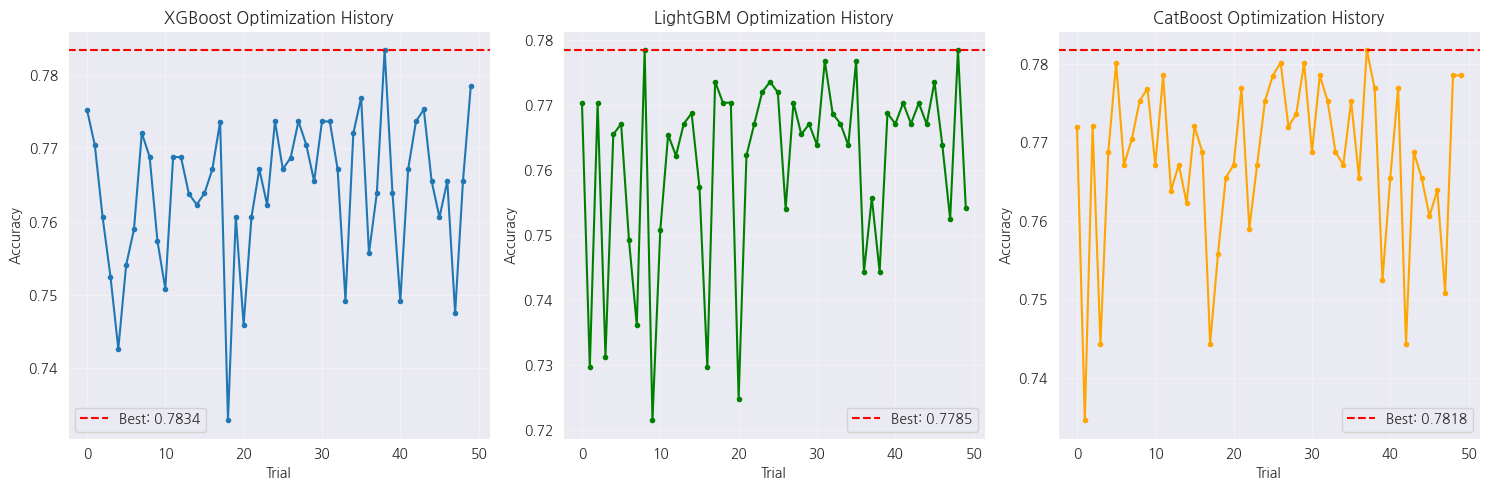

In [16]:
# Optimization History
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

"""
    study_data['number']: trial 번호
    study_data['value']: 해당 trial의 최종 평가 점수
"""

# XGBoost
study_data = study_xgb.trials_dataframe()
axes[0].plot(study_data['number'], study_data['value'], marker='o', markersize=3)
# 최고 성능 위치 - 빨간 점선 가로줄
axes[0].axhline(
    y=study_xgb.best_value,
    color='r', linestyle='--',
    label=f'Best: {study_xgb.best_value:.4f}'
)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('XGBoost Optimization History')
axes[0].legend()
axes[0].grid(alpha=0.3)

# LightGBM
study_data = study_lgbm.trials_dataframe()
axes[1].plot(study_data['number'], study_data['value'], marker='o', markersize=3, color='green')
# 최고 성능 위치 - 빨간 점선 가로줄
axes[1].axhline(
    y=study_lgbm.best_value,
    color='r', linestyle='--',
    label=f'Best: {study_lgbm.best_value:.4f}'
)
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('LightGBM Optimization History')
axes[1].legend()
axes[1].grid(alpha=0.3)

# CatBoost
study_data = study_catboost.trials_dataframe()
axes[2].plot(study_data['number'], study_data['value'], marker='o', markersize=3, color='orange')
# 최고 성능 위치 - 빨간 점선 가로줄
axes[2].axhline(
    y=study_catboost.best_value,
    color='r', linestyle='--',
    label=f'Best: {study_catboost.best_value:.4f}'
)
axes[2].set_xlabel('Trial')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('CatBoost Optimization History')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# 파라미터 중요도
# XGBoost 파라미터 중요도
fig = plot_param_importances(study_xgb)
fig.update_layout(title='XGBoost - Parameter Importances', height=500)
fig.show()

# LightGBM 파라미터 중요도
fig = plot_param_importances(study_lgbm)
fig.update_layout(title='LightGBM - Parameter Importances', height=500)
fig.show()

# CatBoost 파라미터 중요도
fig = plot_param_importances(study_catboost)
fig.update_layout(title='CatBoost - Parameter Importances', height=500)
fig.show()

## 4. 최종 평가 및 비교

**비교 대상**
- Optuna 최적화 결과
- GridSearchCV(제한적 범위)
- RandomizedSearchCV(동일 시도 횟수)
- 기본 설정(Baseline)

In [18]:
# Optuna 최적 모델 테스트
optuna_results = []

# XGBoost
xgb_best = XGBClassifier(
    **study_xgb.best_params,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)
xgb_best.fit(X_train, y_train)
y_pred_xgb = xgb_best.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
# average='weight': 데이터 개수가 더 많은 클래스를 더 중요하게 반영.
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

optuna_results.append({
    'Model': 'XGBoost',
    'Method': 'Optuna',
    'CV Score': study_xgb.best_value,
    'Test Accuracy': xgb_acc,
    'Test F1': xgb_f1,
    'Time': xgb_time
})

# LightGBM
lgbm_best = LGBMClassifier(
    **study_lgbm.best_params,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgbm_best.fit(X_train, y_train)
y_pred_lgbm = lgbm_best.predict(X_test)
lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
lgbm_f1 = f1_score(y_test, y_pred_lgbm, average='weighted')

optuna_results.append({
    'Model': 'LightGBM',
    'Method': 'Optuna',
    'CV Score': study_lgbm.best_value,
    'Test Accuracy': lgbm_acc,
    'Test F1': lgbm_f1,
    'Time': lgbm_time
})

# CatBoost
catboost_best = CatBoostClassifier(
    **study_catboost.best_params,
    random_state=RANDOM_STATE,
    verbose=0
)
catboost_best.fit(X_train, y_train)
y_pred_cat = catboost_best.predict(X_test)
catboost_acc = accuracy_score(y_test, y_pred_cat)
catboost_f1 = f1_score(y_test, y_pred_cat, average='weighted')

optuna_results.append({
    'Model': 'CatBoost',
    'Method': 'Optuna',
    'CV Score': study_catboost.best_value,
    'Test Accuracy': catboost_acc,
    'Test F1': catboost_f1,
    'Time': catboost_time
})

# 출력 결과 확인
optuna_df = pd.DataFrame(optuna_results)
print(optuna_df.to_string(index=False))

   Model Method  CV Score  Test Accuracy  Test F1      Time
 XGBoost Optuna  0.783393       0.746753 0.742259  1.578164
LightGBM Optuna  0.778542       0.772727 0.768694 39.889703
CatBoost Optuna  0.781807       0.733766 0.731930  7.566993


In [19]:
# GridSearchCV로 비교해보기
grid_results = []

# XGBoost GridSearch
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

start_time = time.time()
grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

# 학습
grid_xgb.fit(X_train, y_train)
grid_xgb_time = time.time() - start_time

# 예측
y_pred = grid_xgb.predict(X_test)

grid_results.append({
    'Model': 'XGBoost',
    'Method': 'GridSearch',
    'CV Score': grid_xgb.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': grid_xgb_time
})

# LightGBM GridSearch
param_grid_lgbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50]
}

start_time = time.time()
grid_lgbm = GridSearchCV(
    LGBMClassifier(
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    param_grid_lgbm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

# 학습
grid_lgbm.fit(X_train, y_train)
grid_lgbm_time = time.time() - start_time

# 예측
y_pred = grid_lgbm.predict(X_test)
grid_results.append({
    'Model': 'LightGBM',
    'Method': 'GridSearch',
    'CV Score': grid_lgbm.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': grid_lgbm_time
})

# CatBoost GridSearch
param_grid_cat = {
    'iterations': [100, 200],
    'learning_rate': [0.01, 0.1],
    'depth': [4, 6]
}

start_time = time.time()
grid_cat = GridSearchCV(
    CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0
    ),
    param_grid_cat,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

# 학습
grid_cat.fit(X_train, y_train)
grid_cat_time = time.time() - start_time

# 예측
y_pred = grid_cat.predict(X_test)
grid_results.append({
    'Model': 'CatBoost',
    'Method': 'GridSearch',
    'CV Score': grid_cat.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': grid_cat_time
})

grid_df = pd.DataFrame(grid_results)
print(grid_df.to_string(index=False))

   Model     Method  CV Score  Test Accuracy  Test F1      Time
 XGBoost GridSearch  0.759043       0.746753 0.740695  0.372365
LightGBM GridSearch  0.763908       0.733766 0.721583 12.992891
CatBoost GridSearch  0.776929       0.733766 0.725610  0.512415


In [20]:
# RandomizedSearchCV 비교하기
random_results = []

# XGBoost RandomSearch
param_dist_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

start_time = time.time()
random_xgb = RandomizedSearchCV(
    XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

# 학습
random_xgb.fit(X_train, y_train)
random_xgb_time = time.time() - start_time

# 예측
y_pred = random_xgb.predict(X_test)
random_results.append({
    'Model': 'XGBoost',
    'Method': 'RandomSearch',
    'CV Score': random_xgb.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': random_xgb_time
})

# LightGBM RandomSearch
param_dist_lgbm = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 70],
    'max_depth': [3, 5, 10, 15],
    'min_child_samples': [5, 10, 20, 30]
}

start_time = time.time()
random_lgbm = RandomizedSearchCV(
    LGBMClassifier(
        random_state=RANDOM_STATE,
        verbose=-1
    ),
    param_dist_lgbm,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

# 학습
random_lgbm.fit(X_train, y_train)
random_lgbm_time = time.time() - start_time

# 예측
y_pred = random_lgbm.predict(X_test)
random_results.append({
    'Model': 'LightGBM',
    'Method': 'RandomSearch',
    'CV Score': random_lgbm.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': random_lgbm_time
})

# CatBoost RandomSearch
param_dist_cat = {
    'iterations': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [3, 4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 10]
}

start_time = time.time()
random_cat = RandomizedSearchCV(
    CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0
    ),
    param_dist_cat,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

# 학습
random_cat.fit(X_train, y_train)
random_cat_time = time.time() - start_time

# 예측
y_pred = random_cat.predict(X_test)
random_results.append({
    'Model': 'CatBoost',
    'Method': 'RandomSearch',
    'CV Score': random_cat.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': random_cat_time
})

# 결과
random_df = pd.DataFrame(random_results)
print(random_df.to_string(index=False))

   Model       Method  CV Score  Test Accuracy  Test F1      Time
 XGBoost RandomSearch  0.768799       0.759740 0.759215  0.672305
LightGBM RandomSearch  0.765534       0.733766 0.729042 82.670618
CatBoost RandomSearch  0.785073       0.740260 0.731377 10.084646


In [21]:
# 종합적 비교

# 1. 전체 결과 통합하기
all_results = pd.concat([optuna_df, grid_df, random_df], ignore_index=True)

print("전체 결과 비교: Optuna vs GridSearch vs RandomSearch")
print(all_results.to_string(index=False))

전체 결과 비교: Optuna vs GridSearch vs RandomSearch
   Model       Method  CV Score  Test Accuracy  Test F1      Time
 XGBoost       Optuna  0.783393       0.746753 0.742259  1.578164
LightGBM       Optuna  0.778542       0.772727 0.768694 39.889703
CatBoost       Optuna  0.781807       0.733766 0.731930  7.566993
 XGBoost   GridSearch  0.759043       0.746753 0.740695  0.372365
LightGBM   GridSearch  0.763908       0.733766 0.721583 12.992891
CatBoost   GridSearch  0.776929       0.733766 0.725610  0.512415
 XGBoost RandomSearch  0.768799       0.759740 0.759215  0.672305
LightGBM RandomSearch  0.765534       0.733766 0.729042 82.670618
CatBoost RandomSearch  0.785073       0.740260 0.731377 10.084646


In [22]:
# 2. 방법별 평균 성능
print("방법별 평균 성능")
method_avg = all_results.groupby('Method').agg({
    'CV Score': 'mean',
    'Test Accuracy': 'mean',
    'Test F1': 'mean',
    'Time': 'mean'
}).round(4)
print(method_avg)

방법별 평균 성능
              CV Score  Test Accuracy  Test F1     Time
Method                                                 
GridSearch      0.7666         0.7381   0.7293   4.6259
Optuna          0.7812         0.7511   0.7476  16.3450
RandomSearch    0.7731         0.7446   0.7399  31.1425


In [23]:
# 3. 모델별 최고 성능
print("모델별 최고 성능 (방법 무관)")
for model in ['XGBoost', 'LightGBM', 'CatBoost']:
    model_data = all_results[all_results['Model'] == model]
    best_idx = model_data['Test Accuracy'].idxmax()
    best = all_results.loc[best_idx]
    print(f"\n{model}:")
    print(f"  최고 방법: {best['Method']}")
    print(f"  Test Accuracy: {best['Test Accuracy']:.4f}")
    print(f"  소요 시간: {best['Time']:.2f}초")

모델별 최고 성능 (방법 무관)

XGBoost:
  최고 방법: RandomSearch
  Test Accuracy: 0.7597
  소요 시간: 0.67초

LightGBM:
  최고 방법: Optuna
  Test Accuracy: 0.7727
  소요 시간: 39.89초

CatBoost:
  최고 방법: RandomSearch
  Test Accuracy: 0.7403
  소요 시간: 10.08초


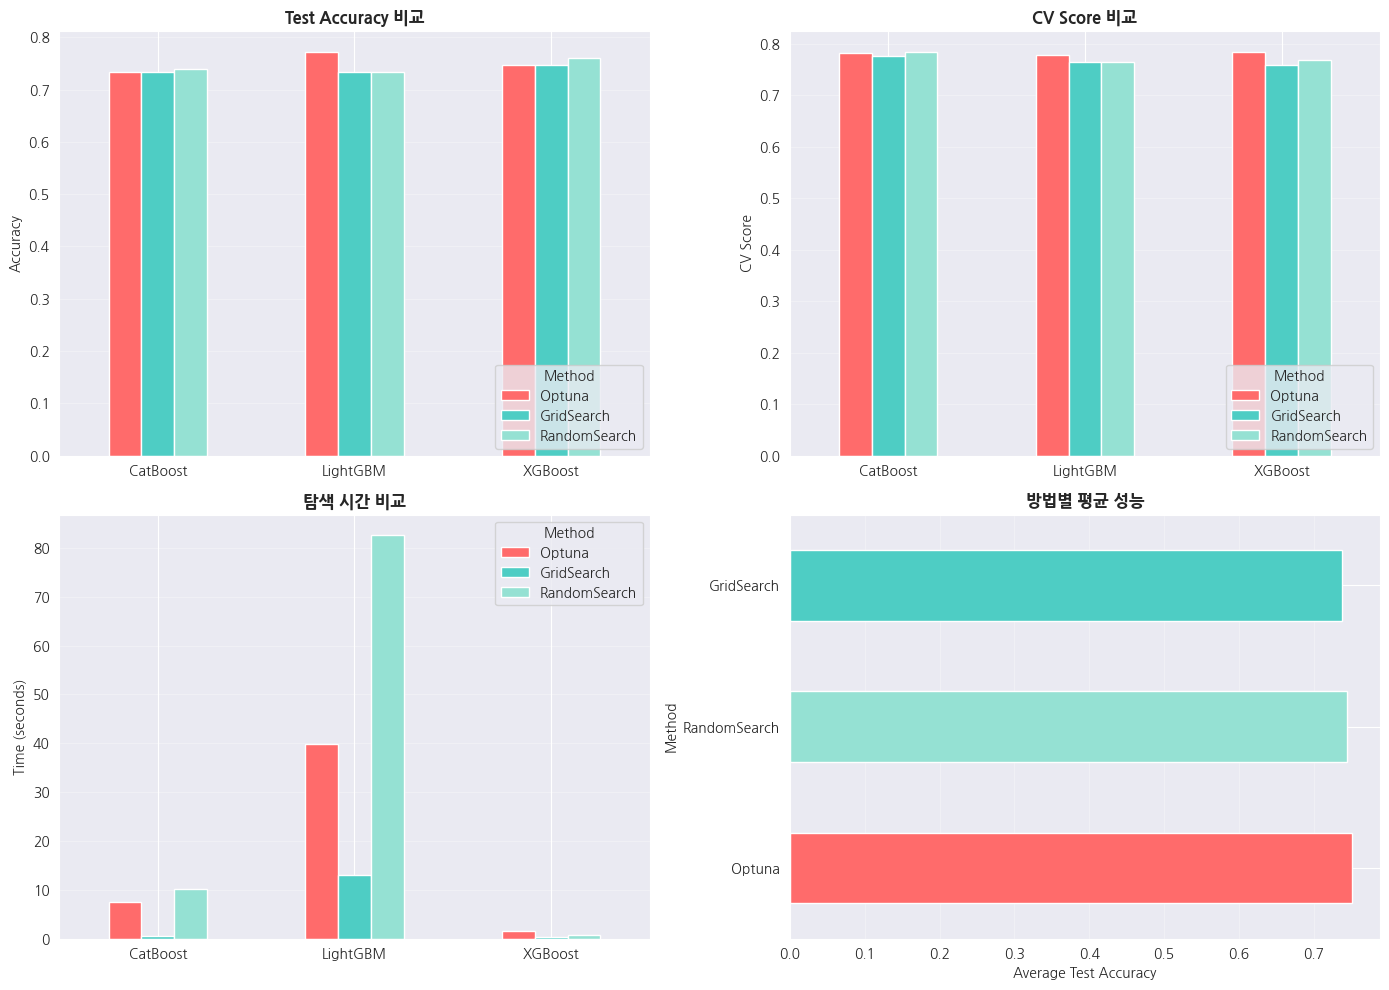

In [24]:
# 비교 시각화하기
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Test Accuracy 비교
ax1 = axes[0, 0]
pivot_acc = all_results.pivot_table(values='Test Accuracy', index='Model', columns='Method')
pivot_acc[['Optuna', 'GridSearch', 'RandomSearch']].plot(kind='bar', ax=ax1,
                                                           color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
ax1.set_title('Test Accuracy 비교', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('')
ax1.legend(title='Method', loc='lower right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# 2. CV Score 비교
ax2 = axes[0, 1]
pivot_cv = all_results.pivot_table(values='CV Score', index='Model', columns='Method')
pivot_cv[['Optuna', 'GridSearch', 'RandomSearch']].plot(kind='bar', ax=ax2,
                                                          color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
ax2.set_title('CV Score 비교', fontsize=12, fontweight='bold')
ax2.set_ylabel('CV Score')
ax2.set_xlabel('')
ax2.legend(title='Method', loc='lower right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# 3. 시간 비교
ax3 = axes[1, 0]
pivot_time = all_results.pivot_table(values='Time', index='Model', columns='Method')
pivot_time[['Optuna', 'GridSearch', 'RandomSearch']].plot(kind='bar', ax=ax3,
                                                            color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
ax3.set_title('탐색 시간 비교', fontsize=12, fontweight='bold')
ax3.set_ylabel('Time (seconds)')
ax3.set_xlabel('')
ax3.legend(title='Method')
ax3.grid(axis='y', alpha=0.3)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

# 4. 방법별 평균 성능
ax4 = axes[1, 1]
method_avg_acc = all_results.groupby('Method')['Test Accuracy'].mean().sort_values(ascending=False)
colors_avg = ['#FF6B6B', '#95E1D3', '#4ECDC4']
method_avg_acc.plot(kind='barh', ax=ax4, color=colors_avg)
ax4.set_xlabel('Average Test Accuracy')
ax4.set_title('방법별 평균 성능', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()